# EDA: MODIS AOD vs AQI Correlation Analysis

This notebook performs exploratory data analysis on per-station MODIS AOD + AQI merged CSVs.

**Focus:** Correlation between AOD (`Optical_Depth_047`, `Optical_Depth_055`) and AQI values **> 50** (i.e., moderate to hazardous air quality).

**Regression methods:**
- **OLS Linear Regression** — baseline fit across all valid points
- **RANSAC Regression** — robust fit using 80% of inlier data, resistant to outliers

## 0. Imports & Config

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 13

# ── CONFIG ──────────────────────────────────────────────────────────────────
CSV_DIR     = '/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2'  # folder with per-station CSVs
AQI_THRESH  = 50          # Only analyse records where AQI > this value
RANSAC_FRAC = 0.80            # RANSAC min_samples as fraction of dataset
AOD_COLS    = ['Optical_Depth_047', 'Optical_Depth_055']  # AOD variables to test
# ────────────────────────────────────────────────────────────────────────────

csv_files = sorted(glob.glob(os.path.join(CSV_DIR, 'MODIS_AQI_*.csv')))
print(f'Found {len(csv_files)} station CSVs')

Found 13 station CSVs


## 1. Load All Stations

In [2]:
def load_station(path):
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df['station_id'] = os.path.basename(path).replace('MODIS_AQI_', '').replace('.csv', '')
    return df

df_all = pd.concat([load_station(f) for f in csv_files], ignore_index=True)

In [3]:
# This finds every value in the AQI column that isn't an integer or float
non_numeric = df_all[~df_all['AQI'].apply(lambda x: isinstance(x, (int, float)))]
print(non_numeric['AQI'].unique())

['185' '102' '39' '68' '110' '91' '118' '55' '54' '47' '83' '71' '40' '94'
 '74' '97' '78' '49' '96' '82' '67' '38' '87' '57' '34' '30' '63' '44'
 '56' '61' '25' '107' '131' '60' '73' '35' '65' '62' '109' '146' '70'
 '140' '120' '72' '69' '115' '89' '112' '159' '101' '167' '-' '64' '16'
 '50' '43' '161' '158' '194' '166' '151' '138' '143' '164' '189' '81'
 '136' '129' '125' '148' '119' '160' '152' '175' '173' '202' '150' '14'
 '51' '168' '121' '153' '23' '95' '104' '32' '59' '26' '27' '42' '126'
 '52' '28' '22' '36' '106' '144' '8' '111' '31' '21' '117' '24' '3' '75'
 '76' '53' '156' '7' '134' '100' '92' '141' '177' '180' '149' '176' '45'
 '17' '2' '48' '29' '12' '9' '1' '80' '20' '15' '13' '10' '33' '77' '19'
 '11' '37' '18' '127' '155' '88' '79' '41' '128' '139' '170' '108' '98'
 '105' '113' '162' '90' '199' '130' '116' '147' '132' '46' '85' '58' '124'
 '103' '86' '84' '135' '114' '171' '212' '169' '222' '179' '216' '172'
 '256' '239']


In [4]:
df_all["AQI"] = pd.to_numeric(df_all["AQI"], errors='coerce')

In [5]:
print(f'Total records loaded : {len(df_all):,}')
print(f'Date range           : {df_all["timestamp"].min().date()} → {df_all["timestamp"].max().date()}')
print(f'Stations             : {df_all["station_id"].nunique()}')
print(f'AQI range            : {df_all["AQI"].min():.0f} – {df_all["AQI"].max():.0f}')
df_all.head()

Total records loaded : 8,075
Date range           : 2022-09-01 → 2026-03-10
Stations             : 13
AQI range            : 1 – 256


,ID,timestamp,Timestamp_MODIS_str,Optical_Depth_047,Optical_Depth_055,AOD_Uncertainty,Column_WV,AngstromExp_470-780,AOD_QA,FineModeFraction,...,CO,NO2,O3,SO2,Temperature,Humidity,Pressure,Wind Speed,Timestamp_DT,station_id
0,28505268571336961948594948504,2022-09-03 10:45:00,20220903_1045,0.55775,0.424250,0.0391,5.968,NaN,1283.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504
1,28505268571336961948594948504,2022-09-03 13:40:00,20220903_1340,0.09700,0.072000,0.0413,4.765,NaN,1089.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504
2,28505268571336961948594948504,2022-09-05 13:25:00,20220905_1325,0.00200,0.001000,0.1235,4.401,NaN,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504
3,28505268571336961948594948504,2022-09-06 14:10:00,20220906_1410,0.27500,0.207000,0.0147,3.476,NaN,1057.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504
4,28505268571336961948594948504,2022-09-07 10:20:00,20220907_1020,0.51900,0.393667,0.0490,5.495,NaN,1282.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504


In [6]:
station_meta = pd.read_csv('/home/slow_data/Air_Quality/Envisoft_station_metadata.csv')

## 2. Data Quality Overview

In [7]:
# Missing value summary
key_cols = ['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'AOD_Uncertainty',
            'Column_WV', 'FineModeFraction', 'AngstromExp_470-780']

missing = df_all[key_cols].isnull().mean().mul(100).round(2).rename('% missing')
print(missing.to_string())

AQI                    80.85
Optical_Depth_047       0.00
Optical_Depth_055       0.00
AOD_Uncertainty         0.02
Column_WV               0.02
FineModeFraction        0.00
AngstromExp_470-780    90.33


In [8]:
df_all = df_all.dropna(subset=['AQI'])

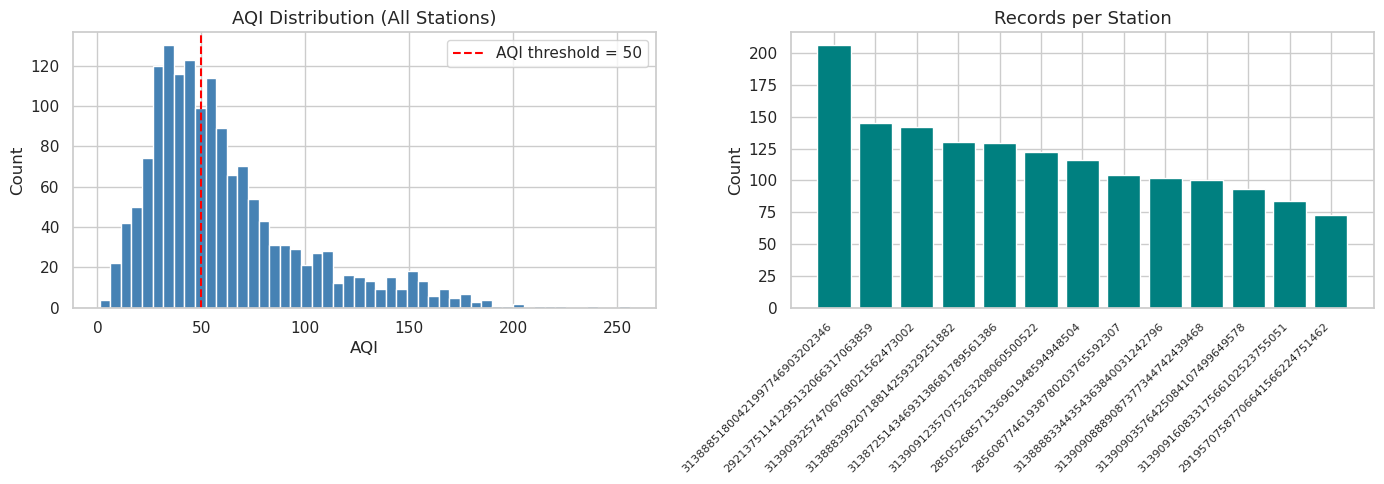

In [9]:
# Distribution of AQI across all stations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all['AQI'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(AQI_THRESH, color='red', linestyle='--', label=f'AQI threshold = {AQI_THRESH}')
axes[0].set_title('AQI Distribution (All Stations)')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Count')
axes[0].legend()

# Records per station (bar)
counts = df_all.groupby('station_id').size().sort_values(ascending=False)
axes[1].bar(range(len(counts)), counts.values, color='teal')
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Records per Station')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Filter: AQI > 50

In [10]:
df_filt = df_all[
    (df_all['AQI'] > AQI_THRESH) &
    df_all['Optical_Depth_047'].notna() &
    df_all['Optical_Depth_055'].notna()
].copy()

print(f'Records after AQI > {AQI_THRESH} filter: {len(df_filt):,} ({100*len(df_filt)/len(df_all):.1f}% of total)')
print(f'Stations with qualifying data: {df_filt["station_id"].nunique()}')

Records after AQI > 50 filter: 797 (51.6% of total)
Stations with qualifying data: 13


## 4. Global AOD vs AQI Scatter (All Stations Combined)

In [11]:
def fit_ols_ransac(x, y, ransac_frac=0.80):
    """
    Fits OLS and RANSAC on paired (x, y) arrays.
    Returns a dict with model objects, predictions, R², MAE, and inlier mask.
    """
    x = np.array(x).reshape(-1, 1)
    y = np.array(y)

    # OLS
    ols = LinearRegression().fit(x, y)
    y_ols = ols.predict(x)
    r2_ols = r2_score(y, y_ols)
    mae_ols = mean_absolute_error(y, y_ols)

    # RANSAC
    min_s = max(2, int(len(x) * ransac_frac))
    ransac = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=min_s,
        random_state=42
    ).fit(x, y)
    inlier_mask = ransac.inlier_mask_
    y_ransac = ransac.predict(x)
    r2_ransac = r2_score(y[inlier_mask], y_ransac[inlier_mask])
    mae_ransac = mean_absolute_error(y[inlier_mask], y_ransac[inlier_mask])

    return dict(
        ols=ols, ransac=ransac, inlier_mask=inlier_mask,
        y_ols=y_ols, y_ransac=y_ransac,
        r2_ols=r2_ols, mae_ols=mae_ols,
        r2_ransac=r2_ransac, mae_ransac=mae_ransac,
        slope_ols=float(ols.coef_[0]), intercept_ols=float(ols.intercept_),
        slope_ransac=float(ransac.estimator_.coef_[0]),
        intercept_ransac=float(ransac.estimator_.intercept_)
    )

print('fit_ols_ransac() helper defined.')

fit_ols_ransac() helper defined.


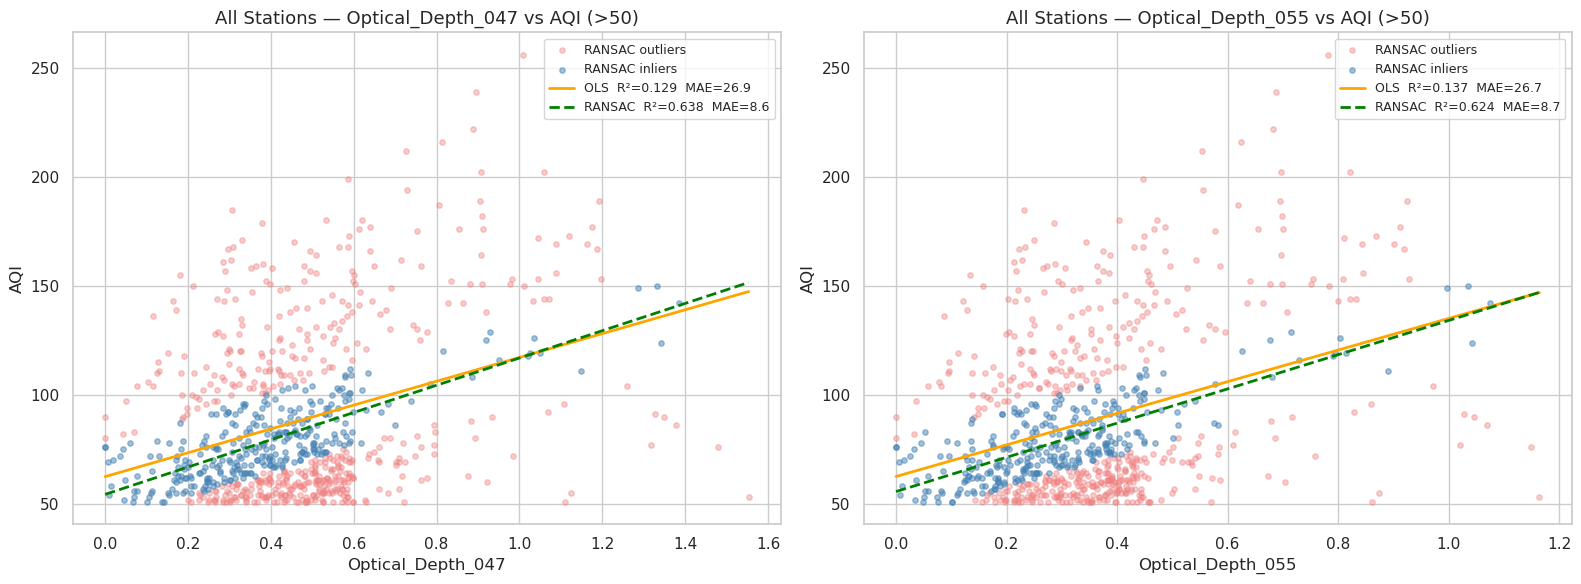

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, aod_col in zip(axes, AOD_COLS):
    sub = df_filt[['AQI', aod_col]].dropna()
    x_vals = sub[aod_col].values
    y_vals = sub['AQI'].values

    fit = fit_ols_ransac(x_vals, y_vals, RANSAC_FRAC)

    # Sort for line plotting
    sort_idx = np.argsort(x_vals)
    xs = x_vals[sort_idx]

    # Scatter: inliers vs outliers
    ax.scatter(x_vals[~fit['inlier_mask']], y_vals[~fit['inlier_mask']],
               color='lightcoral', alpha=0.4, s=15, label='RANSAC outliers')
    ax.scatter(x_vals[fit['inlier_mask']], y_vals[fit['inlier_mask']],
               color='steelblue', alpha=0.5, s=15, label='RANSAC inliers')

    # OLS line
    ax.plot(xs, fit['slope_ols'] * xs + fit['intercept_ols'],
            color='orange', linewidth=2,
            label=f'OLS  R²={fit["r2_ols"]:.3f}  MAE={fit["mae_ols"]:.1f}')

    # RANSAC line
    ax.plot(xs, fit['slope_ransac'] * xs + fit['intercept_ransac'],
            color='green', linewidth=2, linestyle='--',
            label=f'RANSAC  R²={fit["r2_ransac"]:.3f}  MAE={fit["mae_ransac"]:.1f}')

    ax.set_xlabel(aod_col)
    ax.set_ylabel('AQI')
    ax.set_title(f'All Stations — {aod_col} vs AQI (>{AQI_THRESH})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Per-Station Correlation Summary

In [13]:
results = []

for station_id, grp in df_filt.groupby('station_id'):
    for aod_col in AOD_COLS:
        sub = grp[['AQI', aod_col]].dropna()
        if len(sub) < 5:  # skip stations with too few points
            continue

        x = sub[aod_col].values
        y = sub['AQI'].values

        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)

        try:
            fit = fit_ols_ransac(x, y, RANSAC_FRAC)
        except Exception:
            continue

        results.append(dict(
            station_id=station_id,
            aod_col=aod_col,
            n=len(sub),
            n_inliers=fit['inlier_mask'].sum(),
            pearson_r=round(pearson_r, 3),
            pearson_p=round(pearson_p, 4),
            spearman_r=round(spearman_r, 3),
            spearman_p=round(spearman_p, 4),
            ols_slope=round(fit['slope_ols'], 4),
            ols_intercept=round(fit['intercept_ols'], 3),
            ols_r2=round(fit['r2_ols'], 4),
            ols_mae=round(fit['mae_ols'], 3),
            ransac_slope=round(fit['slope_ransac'], 4),
            ransac_intercept=round(fit['intercept_ransac'], 3),
            ransac_r2=round(fit['r2_ransac'], 4),
            ransac_mae=round(fit['mae_ransac'], 3),
        ))

df_results = pd.DataFrame(results)
print(f'Computed correlations for {len(df_results)} station × AOD combinations')
df_results.sort_values('pearson_r', ascending=False)

Computed correlations for 26 station × AOD combinations


,station_id,aod_col,n,n_inliers,pearson_r,pearson_p,spearman_r,spearman_p,ols_slope,ols_intercept,ols_r2,ols_mae,ransac_slope,ransac_intercept,ransac_r2,ransac_mae
0,28505268571336961948594948504,Optical_Depth_047,39,18,0.723,0.0000,0.663,0.0000,76.5699,26.212,0.5221,18.571,86.8176,25.429,0.9541,5.970
1,28505268571336961948594948504,Optical_Depth_055,39,18,0.722,0.0000,0.663,0.0000,97.7036,27.376,0.5219,18.495,110.9902,26.584,0.9562,5.830
4,29195707587706641566224751462,Optical_Depth_047,50,40,0.651,0.0000,0.634,0.0000,104.1694,60.771,0.4234,24.616,117.4871,48.668,0.6881,18.367
5,29195707587706641566224751462,Optical_Depth_055,50,40,0.650,0.0000,0.634,0.0000,133.6685,61.902,0.4230,24.640,150.3670,50.085,0.6861,18.451
17,31390903576425084107499649578,Optical_Depth_055,76,46,0.589,0.0000,0.500,0.0000,149.4957,52.682,0.3474,33.376,164.1766,38.409,0.7163,15.459
16,31390903576425084107499649578,Optical_Depth_047,76,46,0.589,0.0000,0.500,0.0000,116.5430,51.363,0.3474,33.385,127.6058,37.164,0.7140,15.512
18,31390908889087377344742439468,Optical_Depth_047,70,47,0.476,0.0000,0.411,0.0004,63.1647,69.266,0.2269,27.372,77.9695,53.622,0.6141,15.368
19,31390908889087377344742439468,Optical_Depth_055,70,47,0.476,0.0000,0.411,0.0004,80.8015,70.091,0.2266,27.373,99.7033,54.630,0.6144,15.375
3,28560877461938780203765592307,Optical_Depth_055,87,50,0.426,0.0000,0.361,0.0006,97.9356,69.085,0.1816,30.790,131.2168,50.455,0.6630,14.907
2,28560877461938780203765592307,Optical_Depth_047,87,50,0.426,0.0000,0.361,0.0006,76.0404,68.340,0.1815,30.814,101.8263,49.526,0.6619,14.934


## 6. Correlation Heatmap (Pearson R per Station)

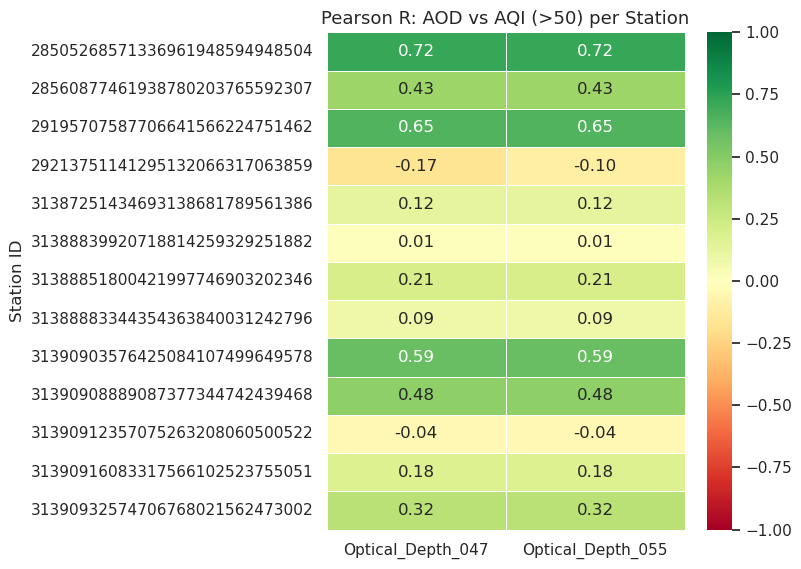

In [14]:
pivot = df_results.pivot(index='station_id', columns='aod_col', values='pearson_r')

fig, ax = plt.subplots(figsize=(8, max(4, len(pivot) * 0.45)))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Pearson R: AOD vs AQI (>{AQI_THRESH}) per Station')
ax.set_xlabel('')
ax.set_ylabel('Station ID')
plt.tight_layout()
plt.show()

## 7. OLS vs RANSAC R² Comparison

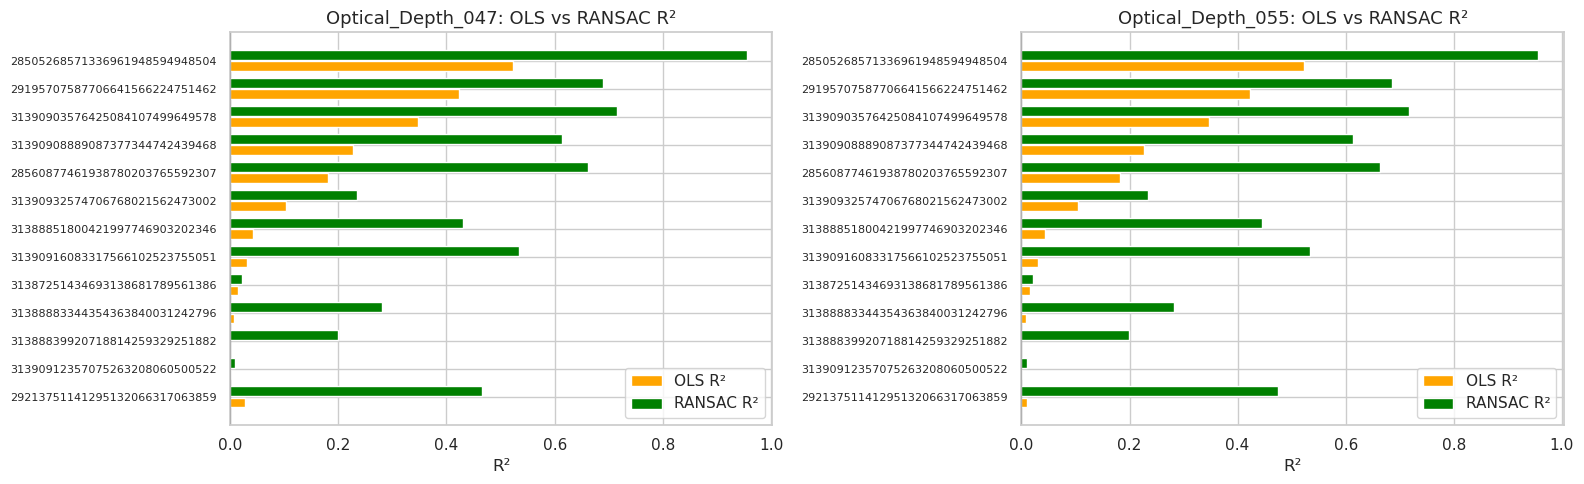

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, aod_col in zip(axes, AOD_COLS):
    sub = df_results[df_results['aod_col'] == aod_col].sort_values('pearson_r', ascending=True)
    y_pos = range(len(sub))

    ax.barh([y - 0.2 for y in y_pos], sub['ols_r2'],   height=0.35, color='orange', label='OLS R²')
    ax.barh([y + 0.2 for y in y_pos], sub['ransac_r2'], height=0.35, color='green',  label='RANSAC R²')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['station_id'], fontsize=8)
    ax.set_xlabel('R²')
    ax.set_title(f'{aod_col}: OLS vs RANSAC R²')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Per-Station Scatter Plots with Both Regression Lines

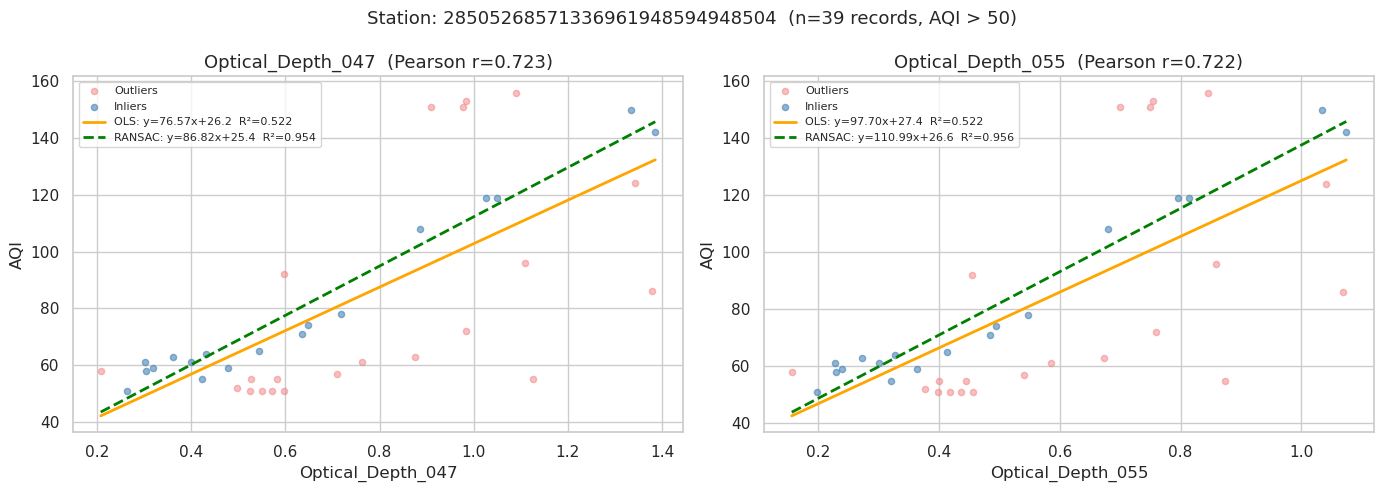

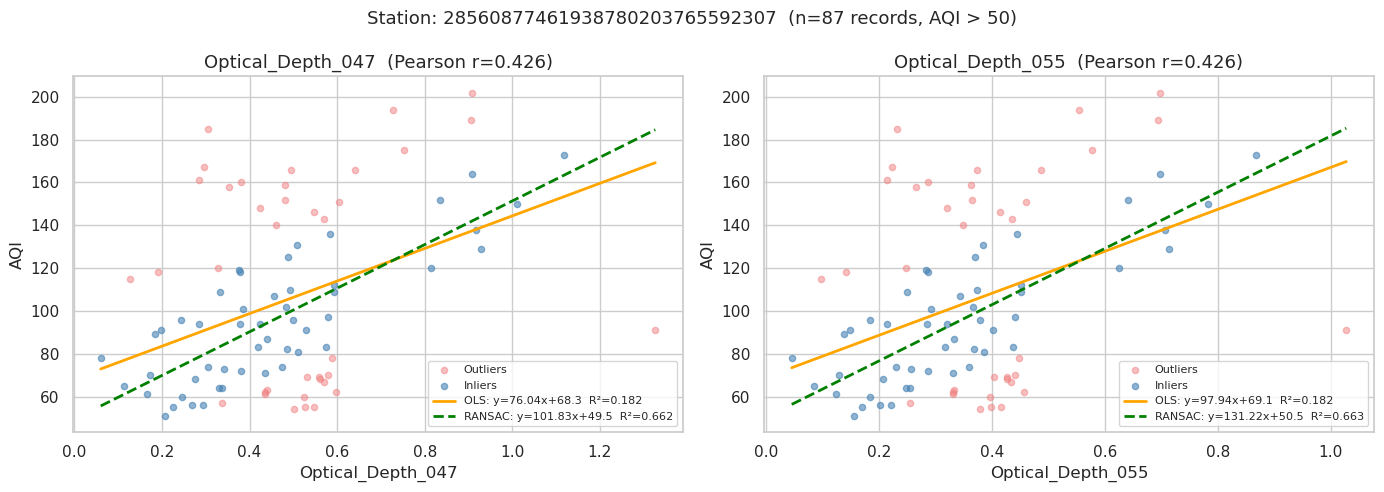

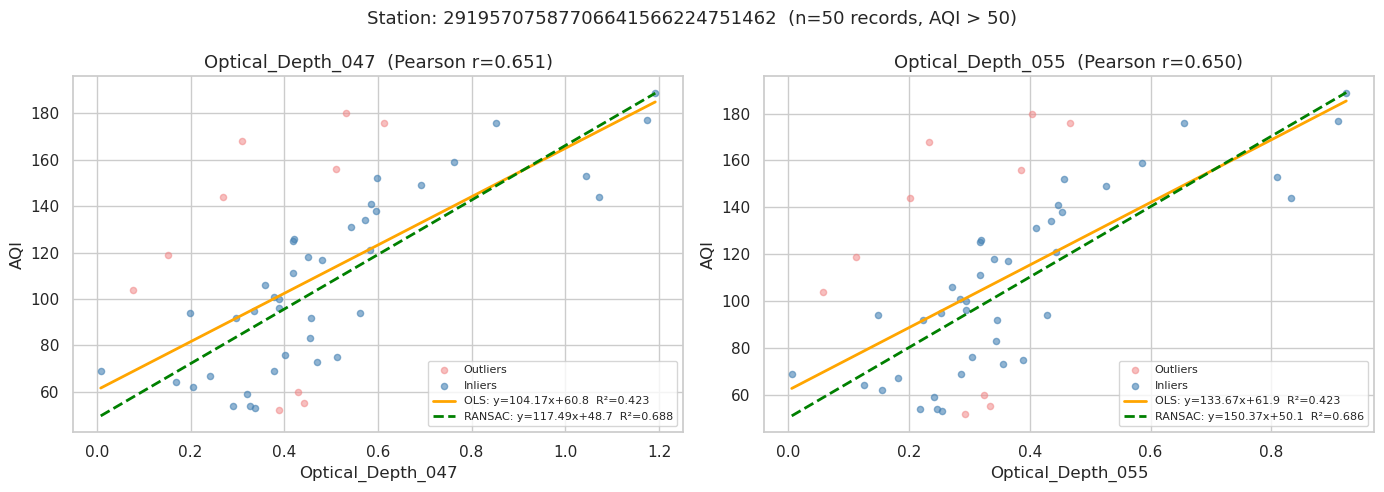

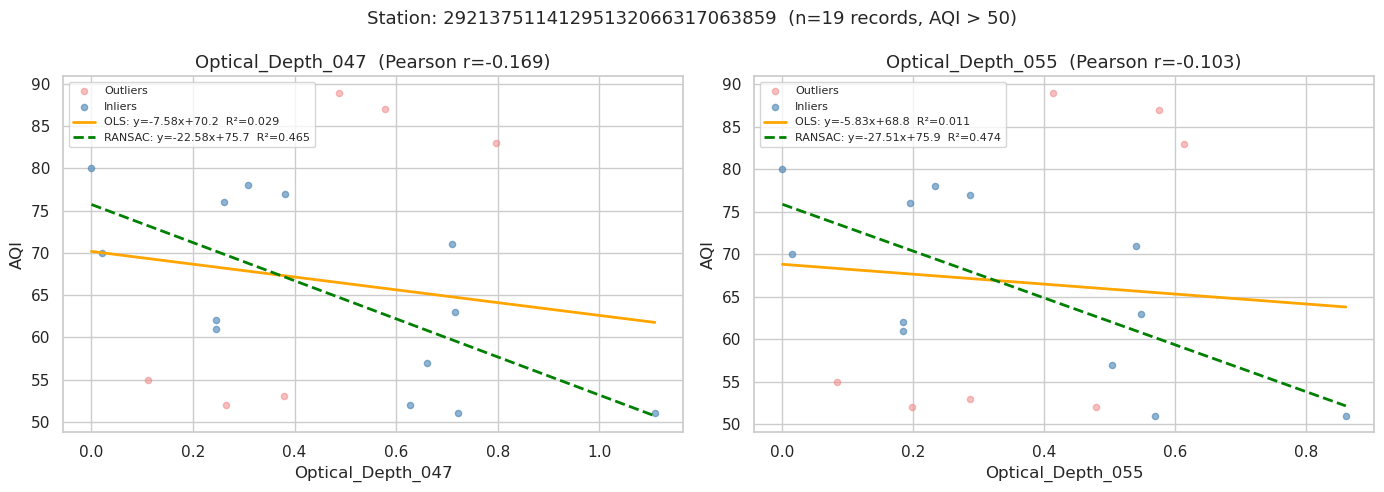

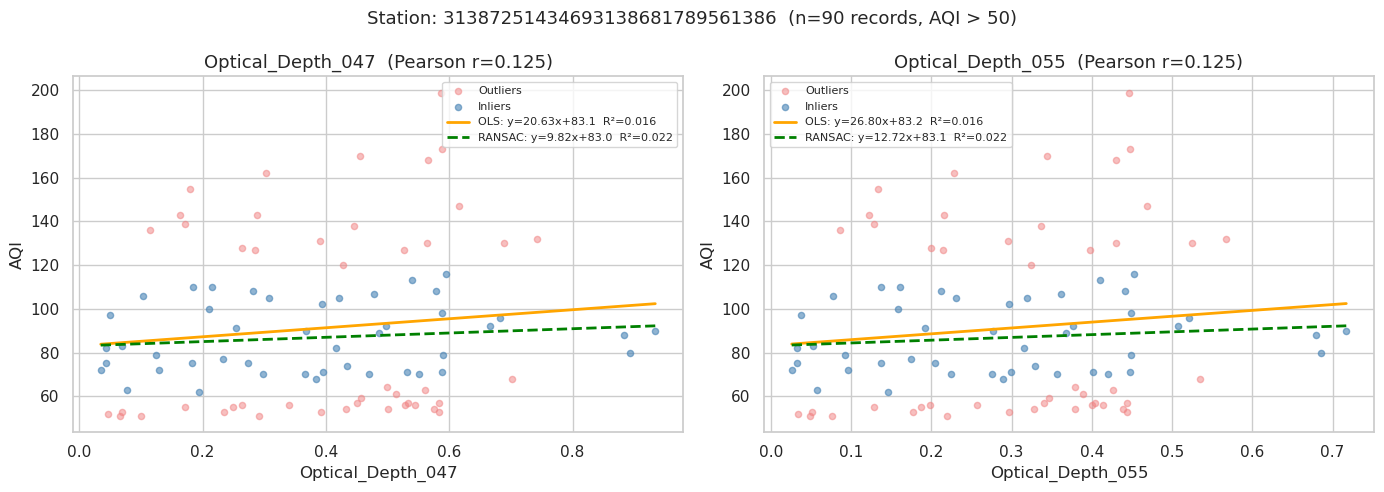

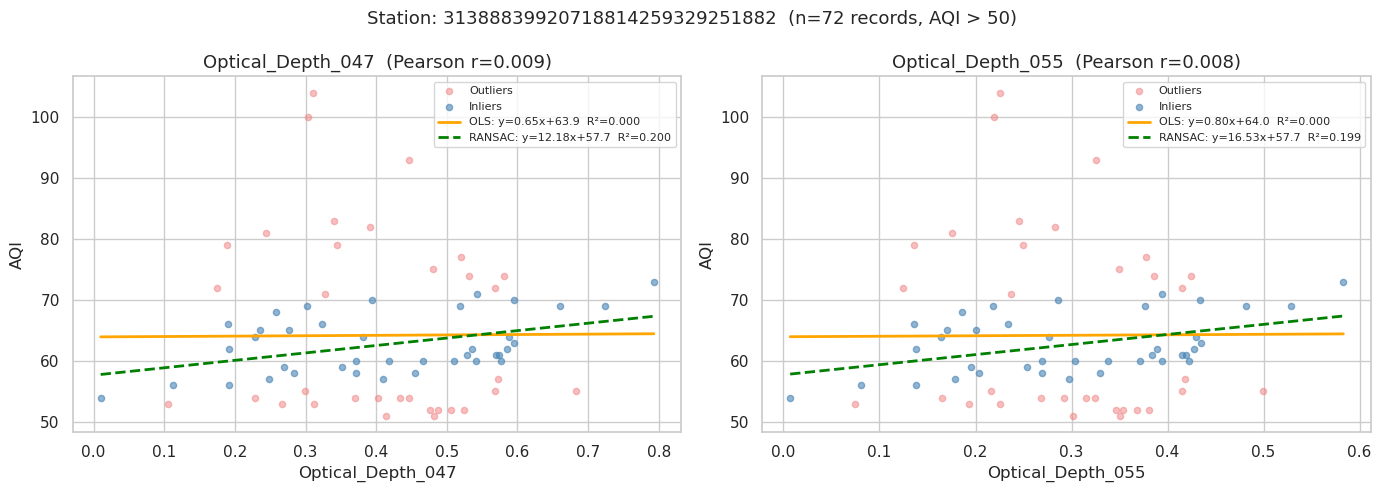

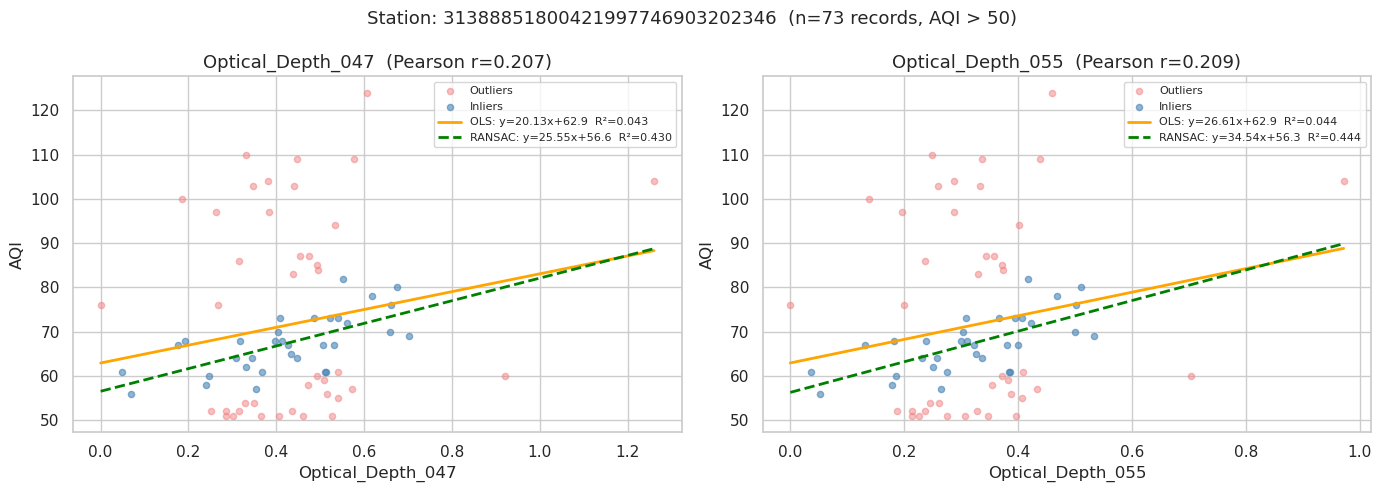

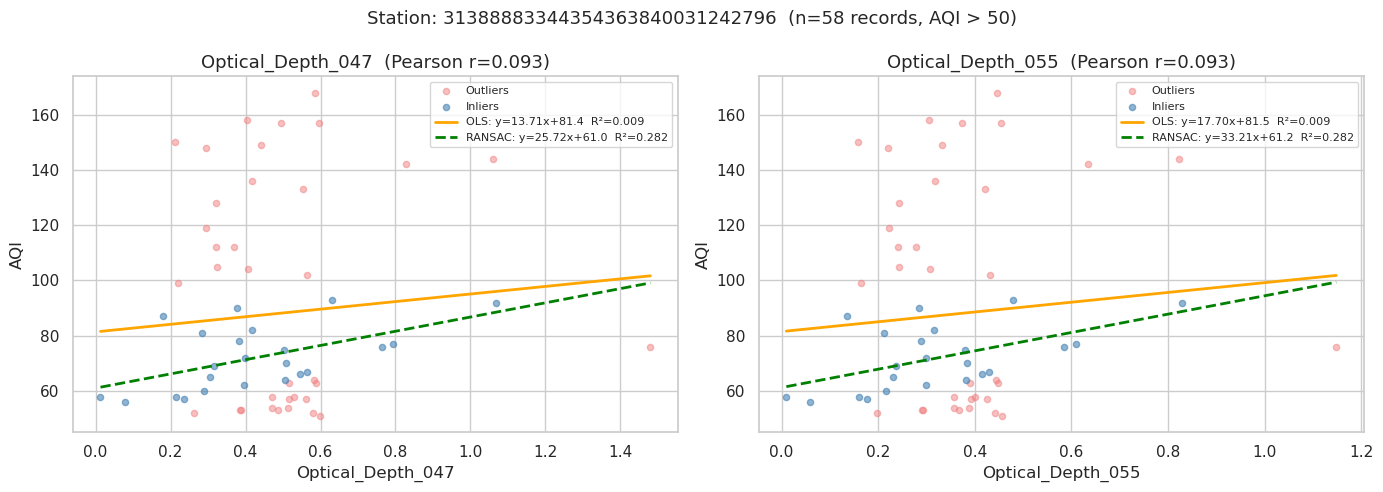

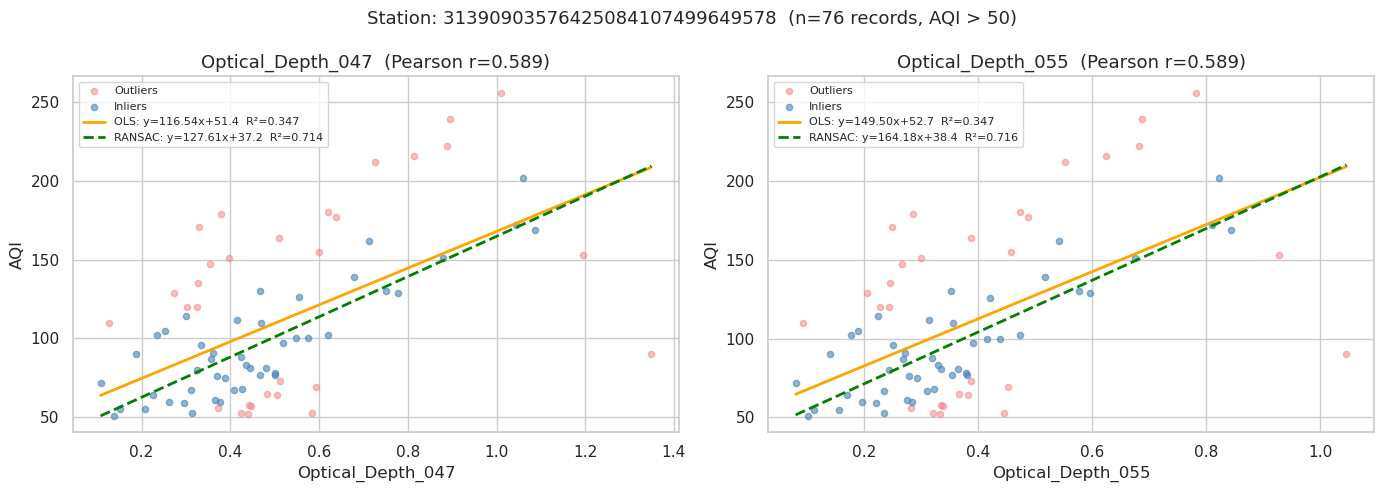

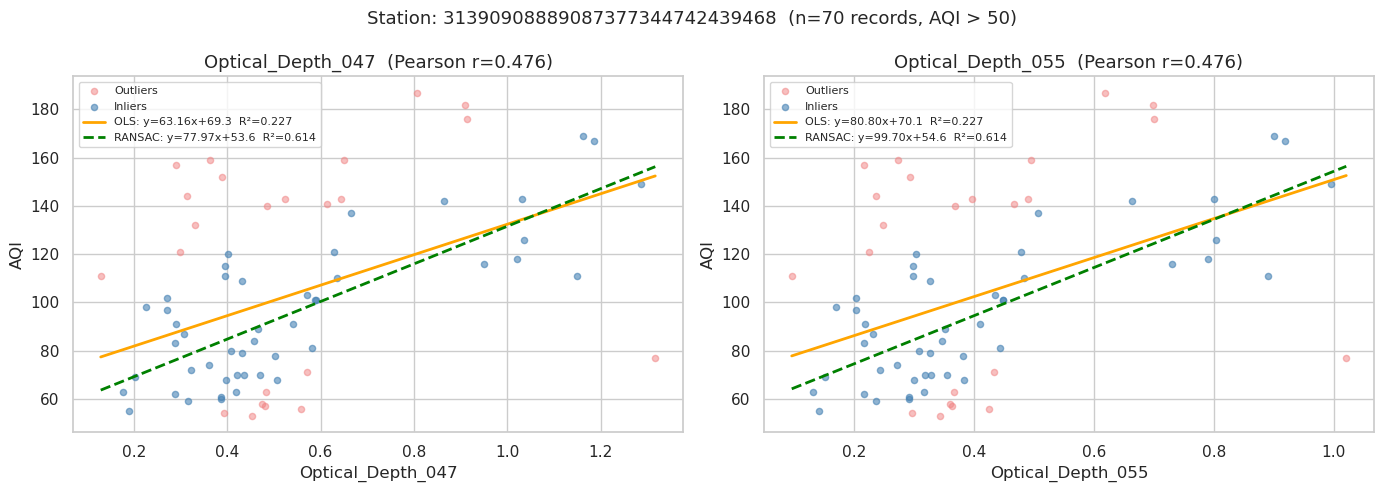

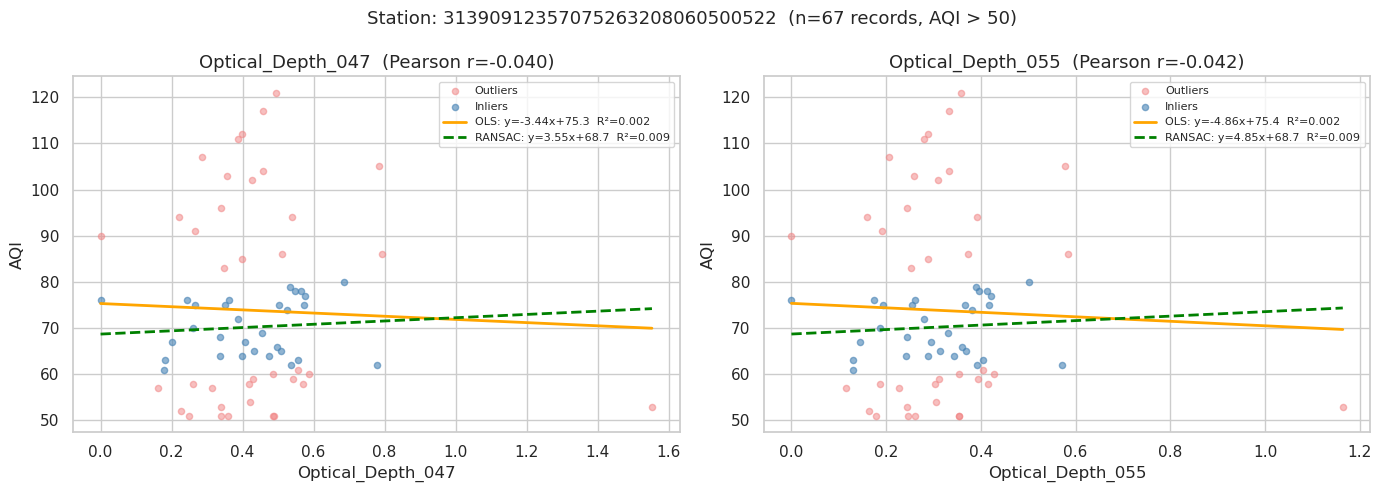

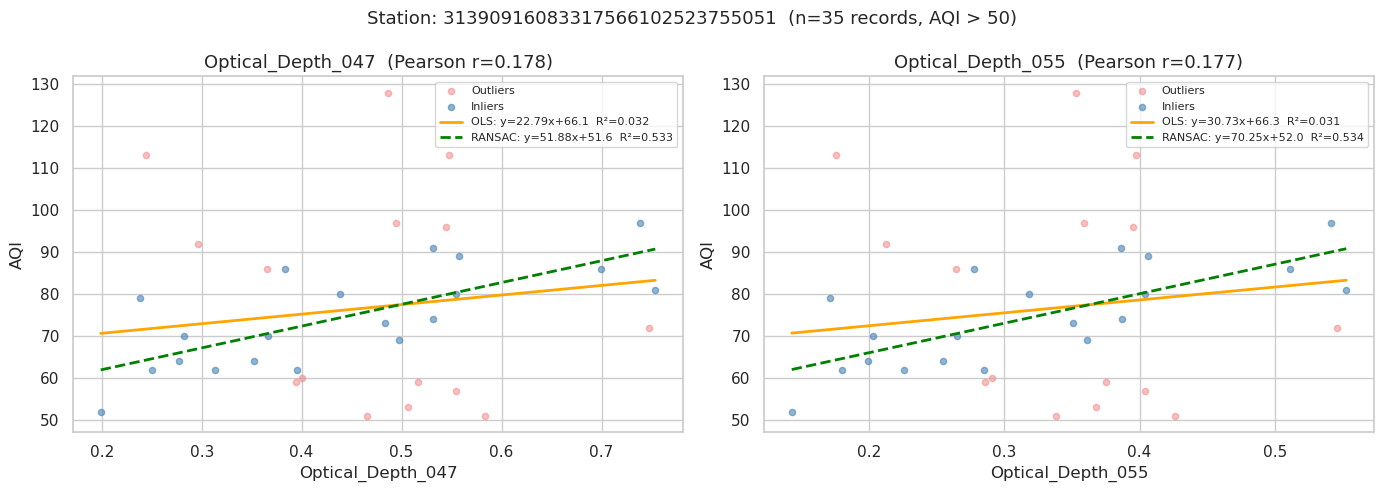

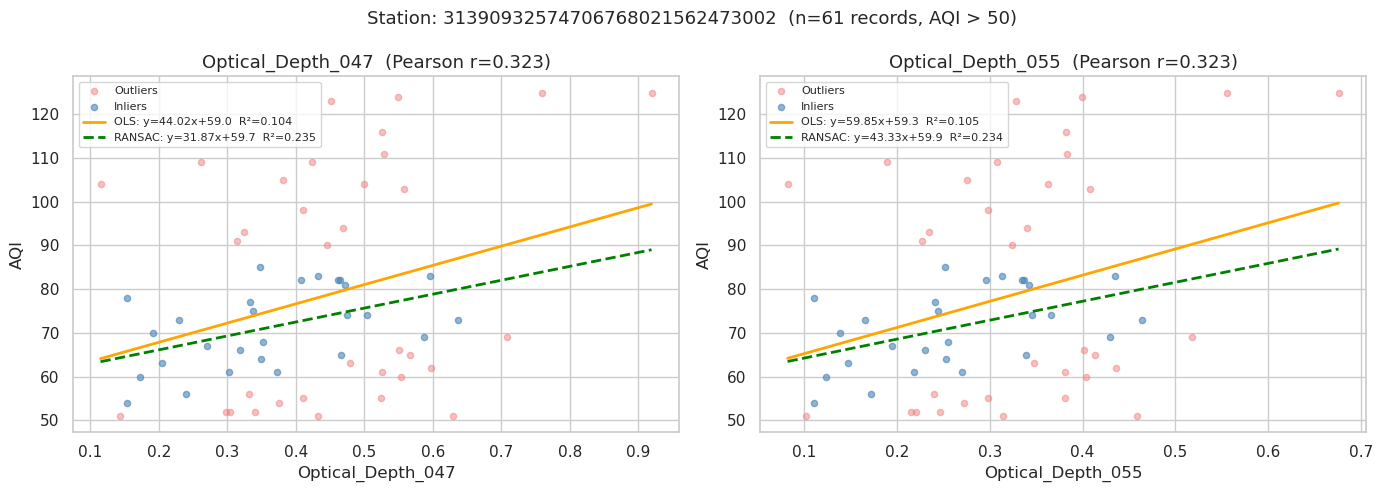

In [16]:
stations = df_filt['station_id'].unique()
n_aod = len(AOD_COLS)

for station_id in stations:
    grp = df_filt[df_filt['station_id'] == station_id]
    
    fig, axes = plt.subplots(1, n_aod, figsize=(7 * n_aod, 5))
    if n_aod == 1:
        axes = [axes]
    
    fig.suptitle(f'Station: {station_id}  (n={len(grp)} records, AQI > {AQI_THRESH})', fontsize=13)
    
    for ax, aod_col in zip(axes, AOD_COLS):
        sub = grp[['AQI', aod_col]].dropna()
        if len(sub) < 5:
            ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(aod_col)
            continue

        x = sub[aod_col].values
        y = sub['AQI'].values
        fit = fit_ols_ransac(x, y, RANSAC_FRAC)

        xs = np.linspace(x.min(), x.max(), 200)

        # Scatter
        ax.scatter(x[~fit['inlier_mask']], y[~fit['inlier_mask']],
                   color='lightcoral', alpha=0.5, s=20, label='Outliers')
        ax.scatter(x[fit['inlier_mask']], y[fit['inlier_mask']],
                   color='steelblue', alpha=0.6, s=20, label='Inliers')

        # Regression lines
        ax.plot(xs, fit['slope_ols'] * xs + fit['intercept_ols'],
                color='orange', lw=2,
                label=f"OLS: y={fit['slope_ols']:.2f}x+{fit['intercept_ols']:.1f}  R²={fit['r2_ols']:.3f}")
        ax.plot(xs, fit['slope_ransac'] * xs + fit['intercept_ransac'],
                color='green', lw=2, linestyle='--',
                label=f"RANSAC: y={fit['slope_ransac']:.2f}x+{fit['intercept_ransac']:.1f}  R²={fit['r2_ransac']:.3f}")

        ax.set_xlabel(aod_col)
        ax.set_ylabel('AQI')
        ax.set_title(f'{aod_col}  (Pearson r={stats.pearsonr(x, y)[0]:.3f})')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 9. Time-Series: AOD & AQI Together per Station

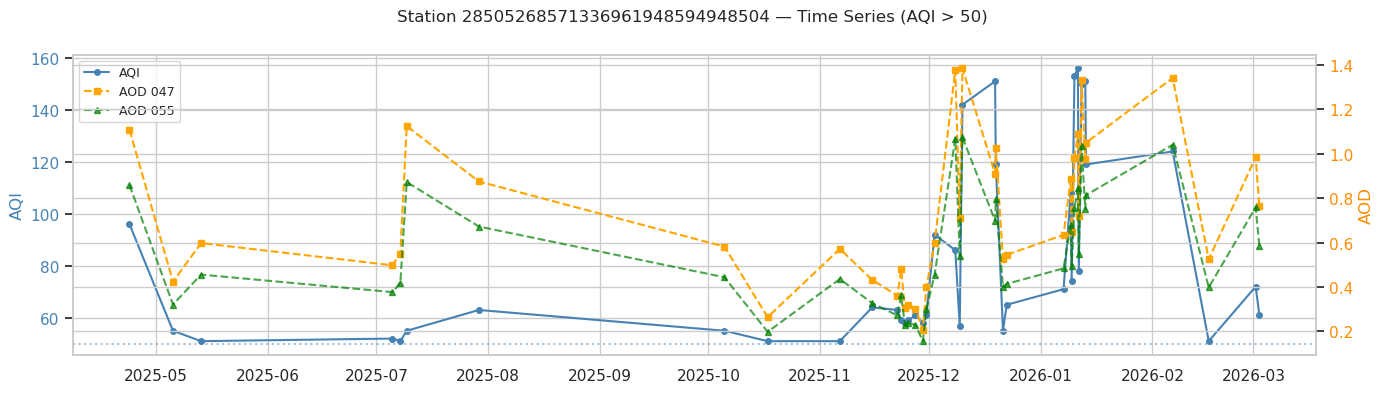

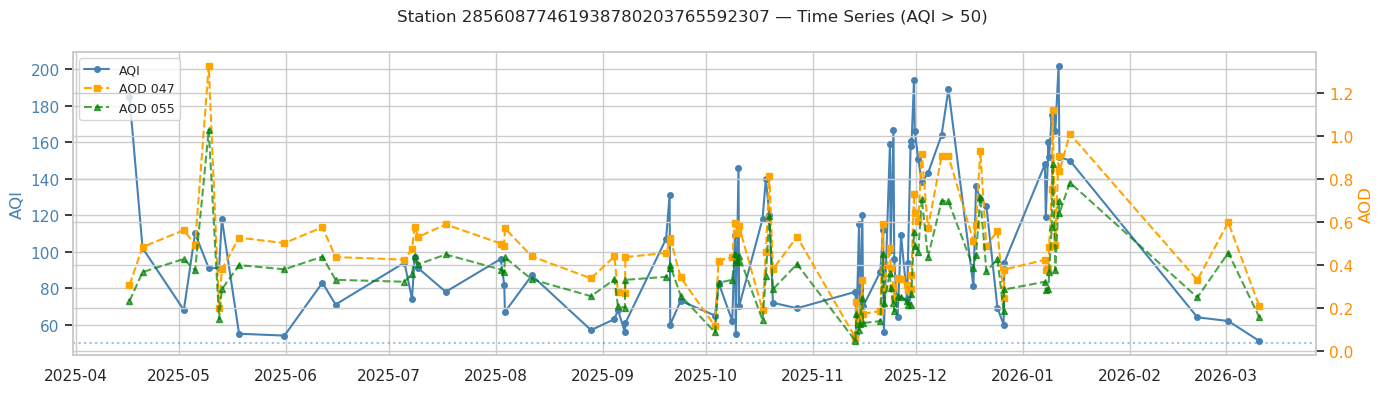

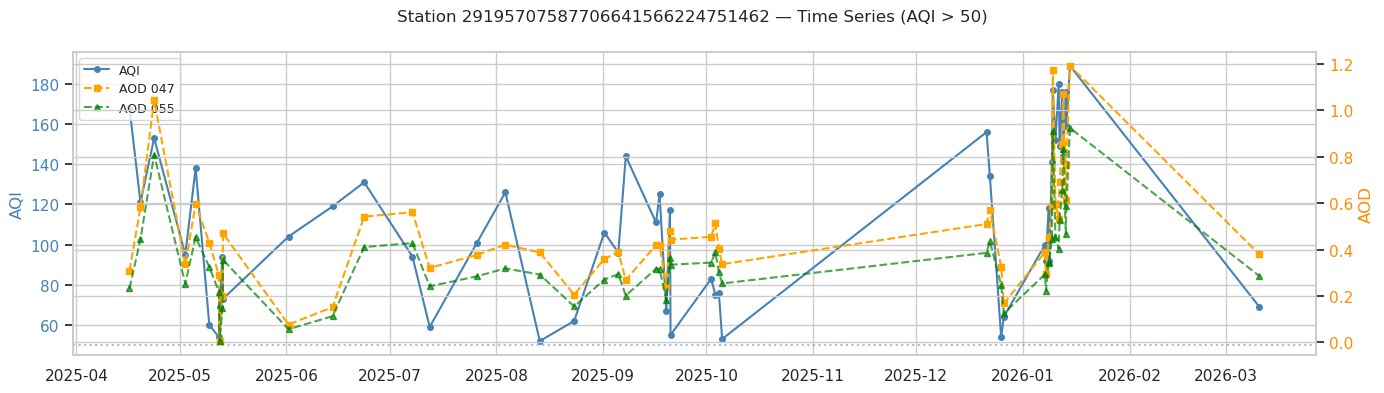

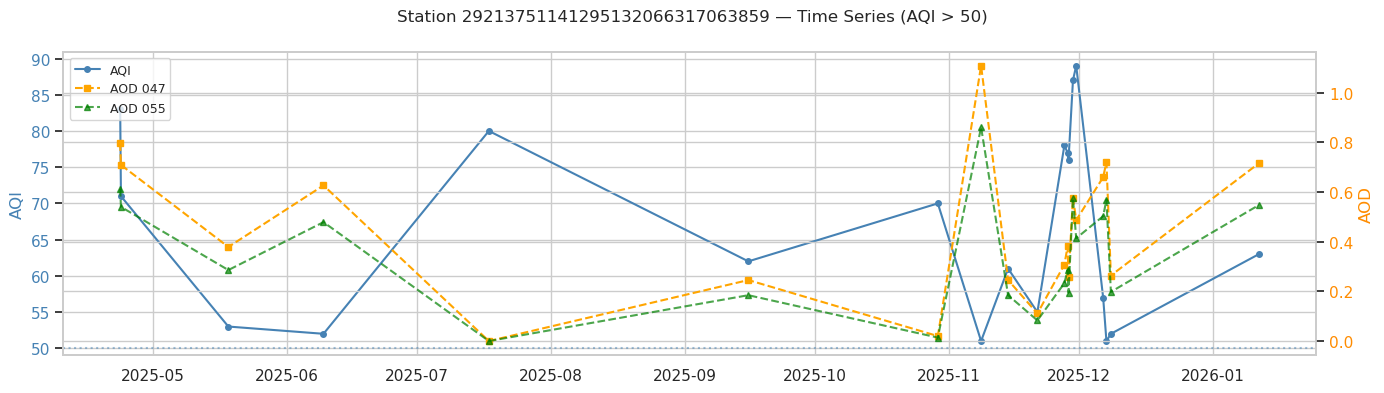

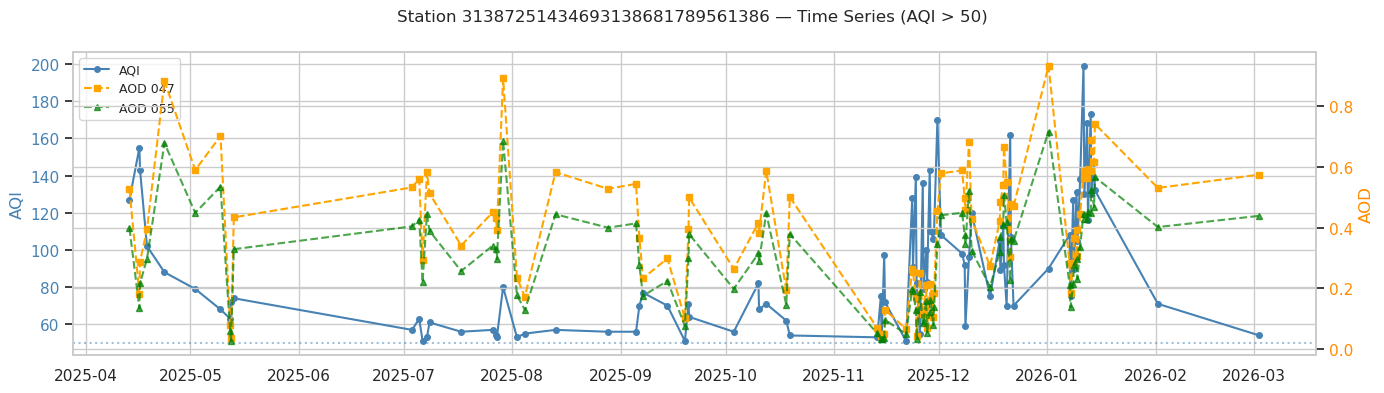

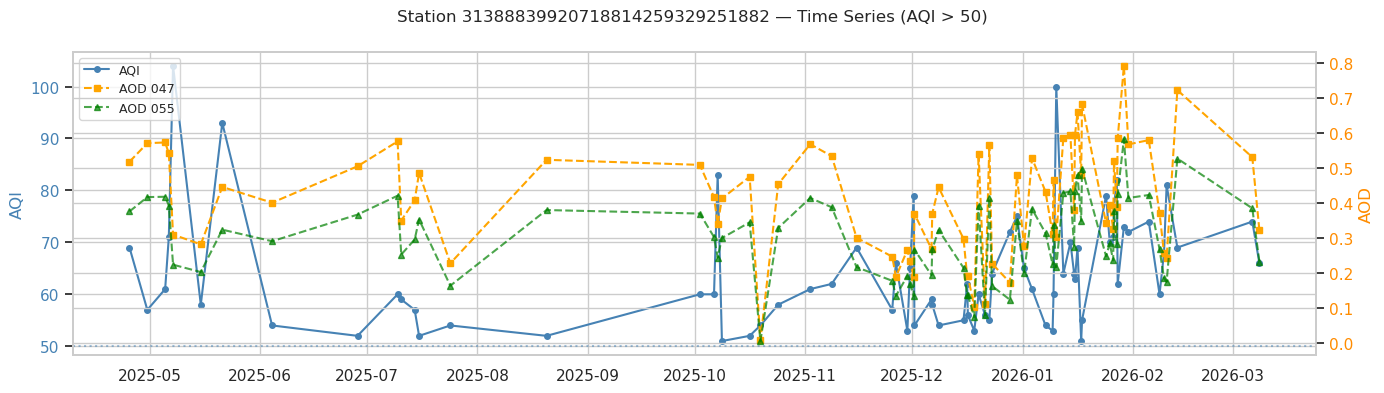

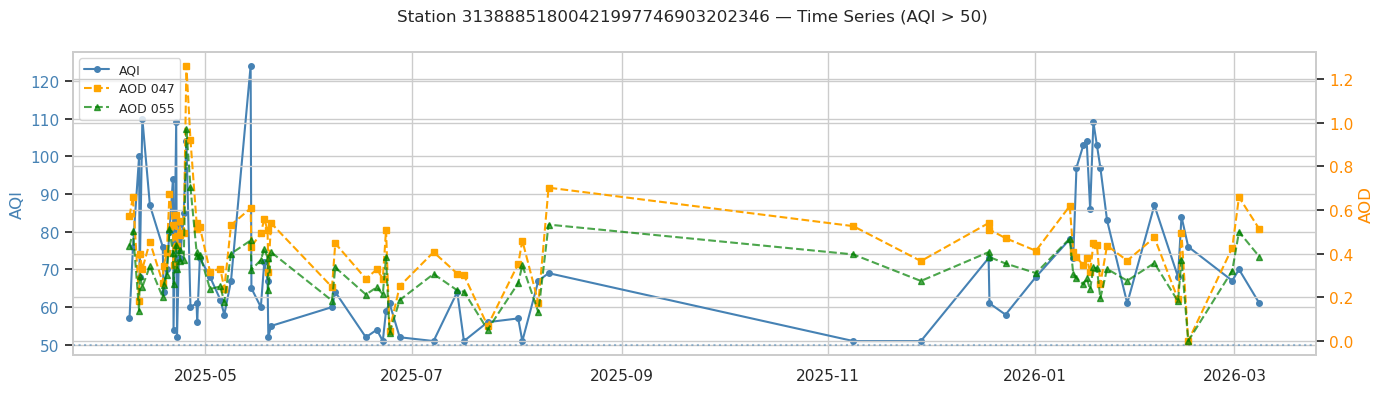

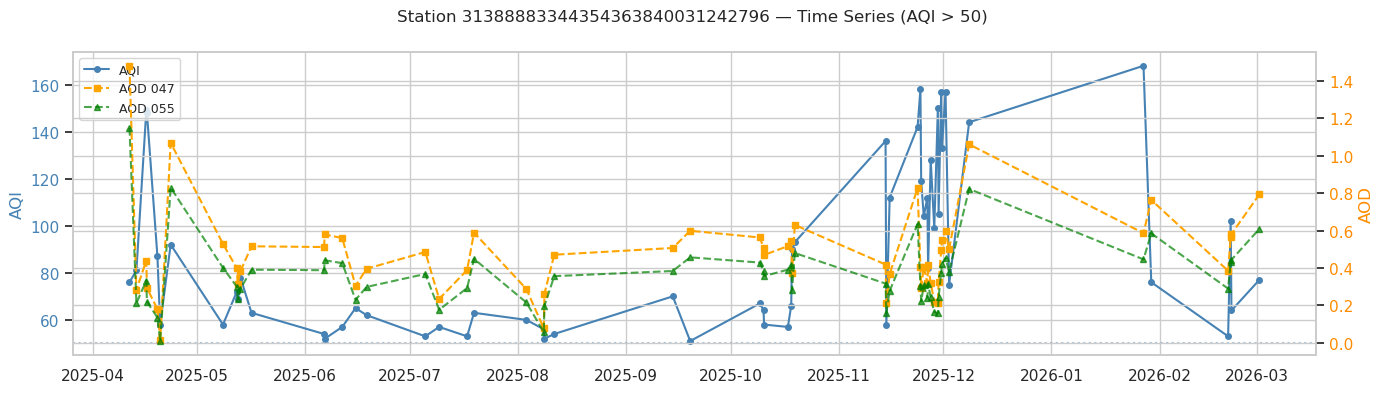

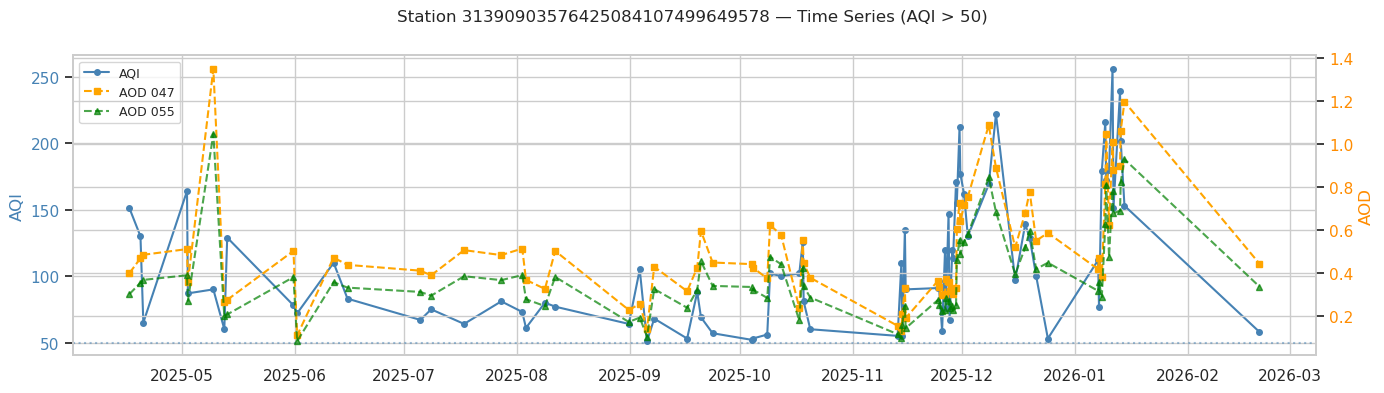

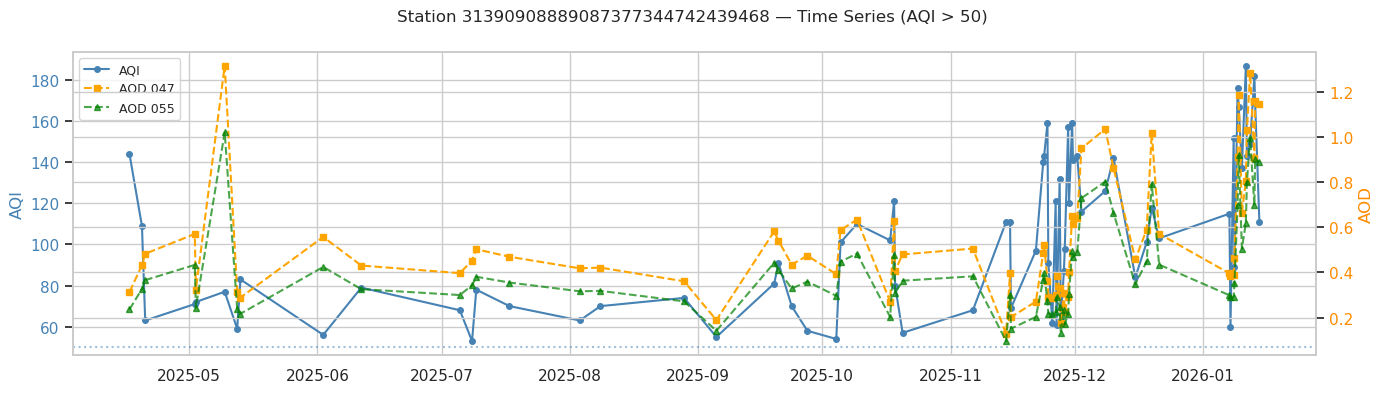

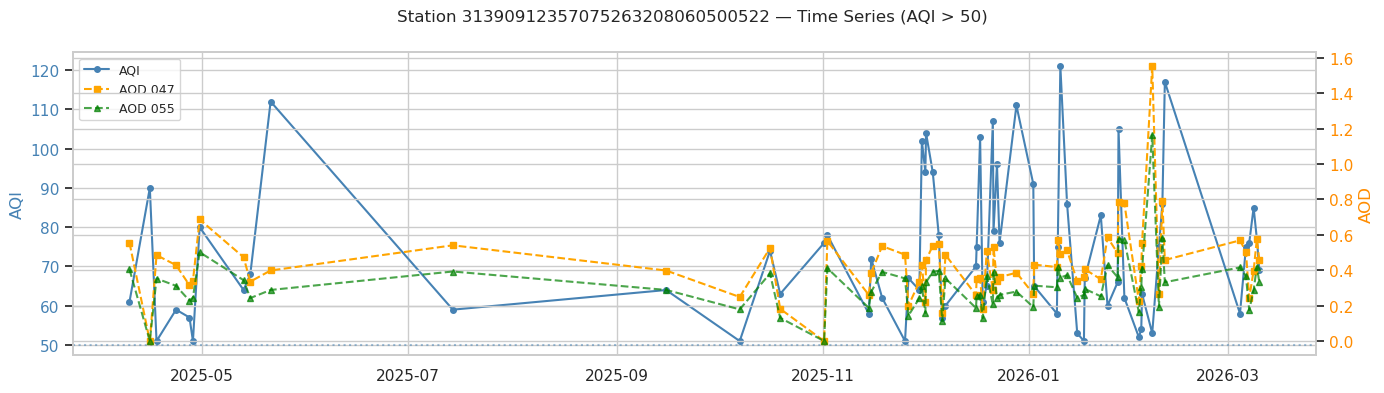

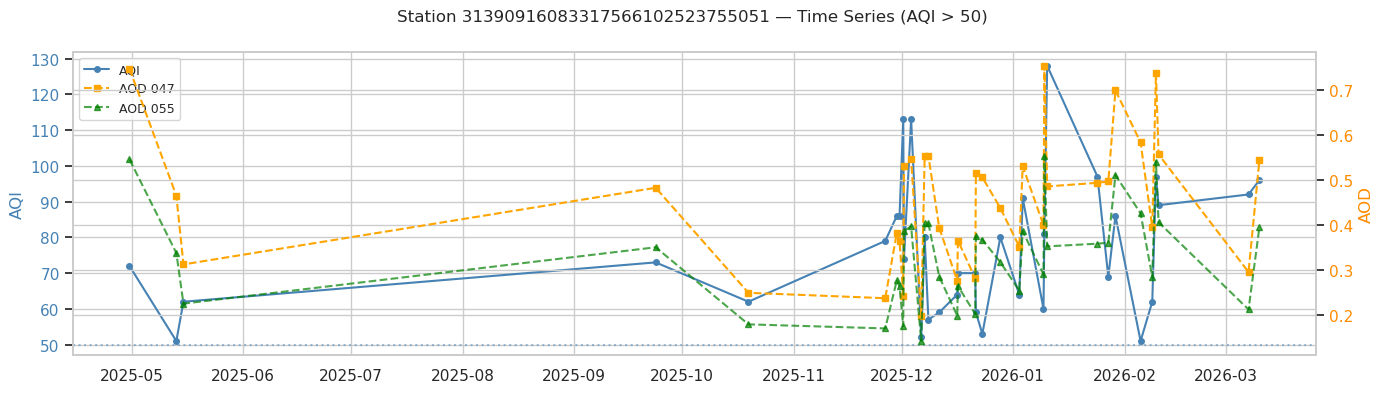

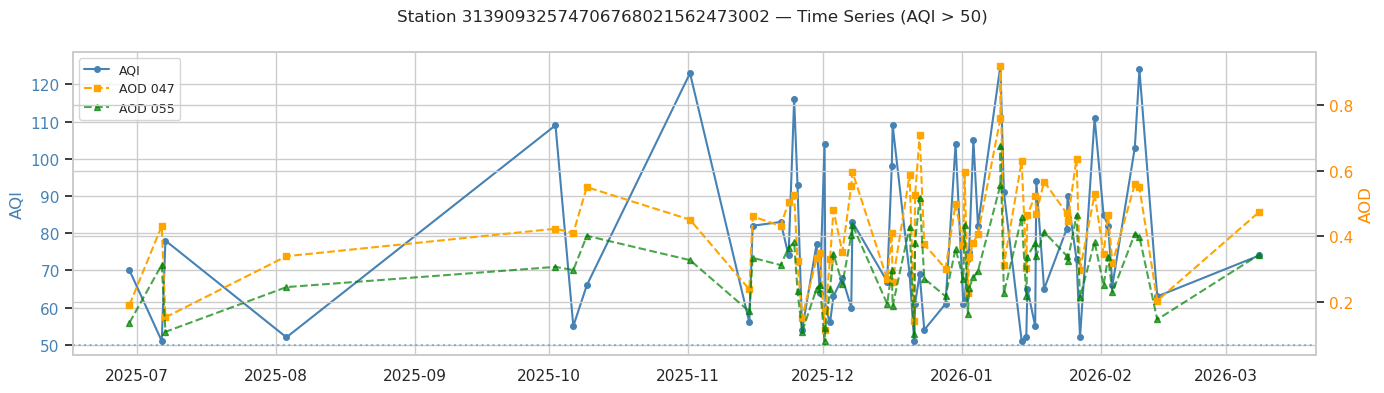

In [17]:
for station_id in stations:
    grp = df_filt[df_filt['station_id'] == station_id].sort_values('timestamp')
    if len(grp) < 3:
        continue

    fig, ax1 = plt.subplots(figsize=(14, 4))
    fig.suptitle(f'Station {station_id} — Time Series (AQI > {AQI_THRESH})', fontsize=12)

    ax1.plot(grp['timestamp'], grp['AQI'], color='steelblue', marker='o', ms=4, label='AQI')
    ax1.set_ylabel('AQI', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.axhline(AQI_THRESH, color='steelblue', linestyle=':', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(grp['timestamp'], grp['Optical_Depth_047'], color='orange', marker='s', ms=4,
             linestyle='--', label='AOD 047')
    ax2.plot(grp['timestamp'], grp['Optical_Depth_055'], color='green', marker='^', ms=4,
             linestyle='--', label='AOD 055', alpha=0.7)
    ax2.set_ylabel('AOD', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 10. Residual Analysis

Best AOD variable by median Pearson R: Optical_Depth_055


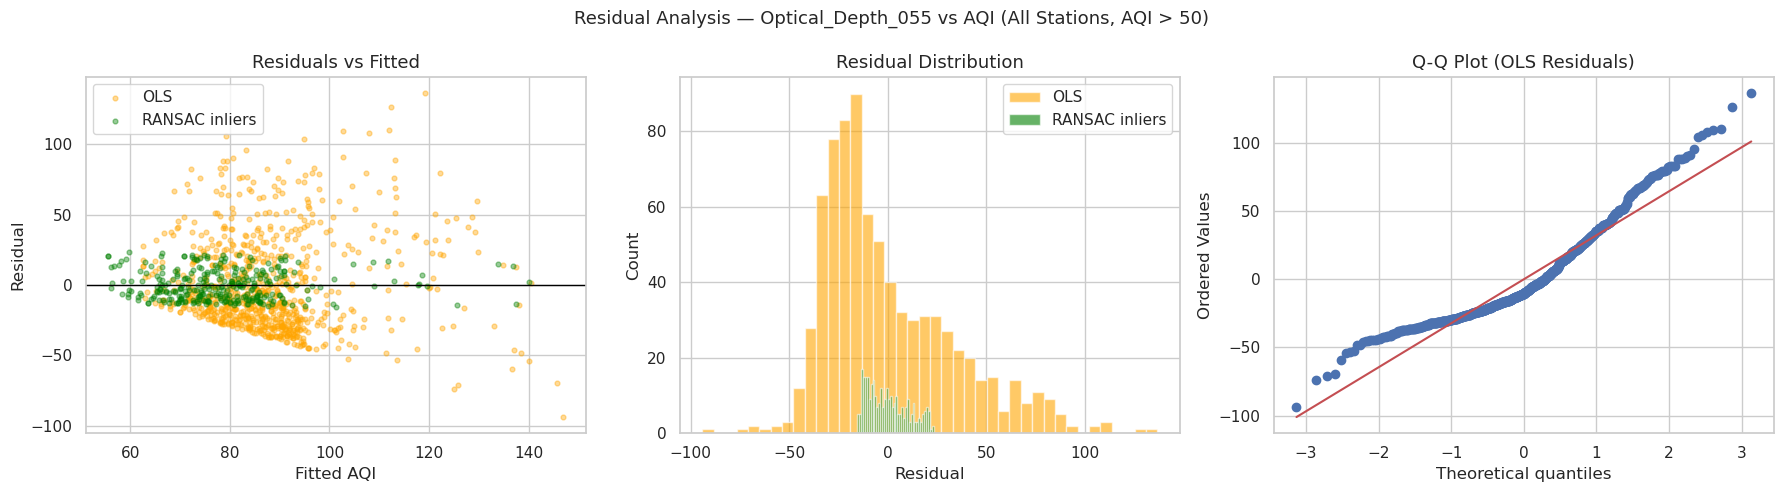

In [18]:
# Focus on best-performing AOD column globally (highest median Pearson R)
best_aod = df_results.groupby('aod_col')['pearson_r'].median().idxmax()
print(f'Best AOD variable by median Pearson R: {best_aod}')

sub = df_filt[['AQI', best_aod, 'station_id']].dropna()
x = sub[best_aod].values
y = sub['AQI'].values
fit = fit_ols_ransac(x, y, RANSAC_FRAC)

residuals_ols    = y - fit['y_ols']
residuals_ransac = y - fit['y_ransac']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Analysis — {best_aod} vs AQI (All Stations, AQI > {AQI_THRESH})', fontsize=13)

# Residuals vs fitted
axes[0].scatter(fit['y_ols'], residuals_ols, alpha=0.4, s=12, color='orange', label='OLS')
axes[0].scatter(fit['y_ransac'][fit['inlier_mask']], residuals_ransac[fit['inlier_mask']],
                alpha=0.4, s=12, color='green', label='RANSAC inliers')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Fitted AQI')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')
axes[0].legend()

# Histogram of residuals
axes[1].hist(residuals_ols, bins=40, alpha=0.6, color='orange', label='OLS')
axes[1].hist(residuals_ransac[fit['inlier_mask']], bins=40, alpha=0.6, color='green', label='RANSAC inliers')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

# Q-Q plot (OLS residuals)
stats.probplot(residuals_ols, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (OLS Residuals)')

plt.tight_layout()
plt.show()

## 11. Summary Table Export

In [19]:
out_path = os.path.join(CSV_DIR, 'correlation_summary.csv')
df_results.to_csv(out_path, index=False)
print(f'Summary saved to: {out_path}')
df_results

Summary saved to: /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/correlation_summary.csv


,station_id,aod_col,n,n_inliers,pearson_r,pearson_p,spearman_r,spearman_p,ols_slope,ols_intercept,ols_r2,ols_mae,ransac_slope,ransac_intercept,ransac_r2,ransac_mae
0,28505268571336961948594948504,Optical_Depth_047,39,18,0.723,0.0000,0.663,0.0000,76.5699,26.212,0.5221,18.571,86.8176,25.429,0.9541,5.970
1,28505268571336961948594948504,Optical_Depth_055,39,18,0.722,0.0000,0.663,0.0000,97.7036,27.376,0.5219,18.495,110.9902,26.584,0.9562,5.830
2,28560877461938780203765592307,Optical_Depth_047,87,50,0.426,0.0000,0.361,0.0006,76.0404,68.340,0.1815,30.814,101.8263,49.526,0.6619,14.934
3,28560877461938780203765592307,Optical_Depth_055,87,50,0.426,0.0000,0.361,0.0006,97.9356,69.085,0.1816,30.790,131.2168,50.455,0.6630,14.907
4,29195707587706641566224751462,Optical_Depth_047,50,40,0.651,0.0000,0.634,0.0000,104.1694,60.771,0.4234,24.616,117.4871,48.668,0.6881,18.367
5,29195707587706641566224751462,Optical_Depth_055,50,40,0.650,0.0000,0.634,0.0000,133.6685,61.902,0.4230,24.640,150.3670,50.085,0.6861,18.451
6,29213751141295132066317063859,Optical_Depth_047,19,13,-0.169,0.4892,-0.162,0.5088,-7.5845,70.178,0.0286,11.187,-22.5787,75.735,0.4648,6.849
7,29213751141295132066317063859,Optical_Depth_055,19,12,-0.103,0.6739,-0.062,0.7998,-5.8274,68.813,0.0107,11.413,-27.5137,75.863,0.4738,6.574
8,31387251434693138681789561386,Optical_Depth_047,90,45,0.125,0.2390,0.141,0.1860,20.6311,83.076,0.0157,28.588,9.8214,83.035,0.0222,13.186
9,31387251434693138681789561386,Optical_Depth_055,90,45,0.125,0.2409,0.141,0.1851,26.7994,83.198,0.0156,28.592,12.7208,83.100,0.0220,13.192
